In [ ]:
import pandas as pd
import pickle as pkl

from rdkit import Chem
from rdkit.Chem import (QED, AllChem, DataStructs, PandasTools,
                    rdDetermineBonds, rdFingerprintGenerator,
                    rdRGroupDecomposition)
import umap
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.9,
    "lines.linewidth": 1.6,
    "lines.markersize": 5,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "figure.dpi": 100,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

SINGLE_COL_IN = 4
H_MED = 3.4

# Best molecule at each step, movement in chemical space

In [4]:
dfs = dict()

dfs["PepEVOLVE - NM"] = pd.read_csv("../../../output/journal/result/nm_pepevolve1/results_evolving_step250.csv")
dfs["PepEVOLVE - NS"] = pd.read_csv("../../../output/journal/result/ns_pepevolve1/results_evolving_step250.csv")
dfs["PepEVOLVE - SM"] = pd.read_csv("../../../output/journal/result/sm_pepevolve1/results_evolving_step250.csv")
dfs["PepEVOLVE - SS"] = pd.read_csv("../../../output/journal/result/ss_pepevolve1/results_evolving_step250.csv")
dfs["PepINVENT"] = pd.read_csv("../../../output/journal/result/pepinvent1/results.csv")
dfs["GA"] = pd.read_csv("../../../output/journal/result/traditional_ga1/results_evolving_step1000.csv")

In [5]:
df_plot = pd.DataFrame()

for name, df in dfs.items():
    df_best_per_step = df.loc[df.groupby("Step")["total_score"].idxmax()].reset_index(drop=True)
    df_best_per_step["run"] = name
    df_plot = pd.concat([df_plot, df_best_per_step], axis=0)
df_plot

,Unnamed: 0,Period,Step,Mask Position,Input_CHUCKLES,Monomers,CHUCKLES,SMILES,Scaffold,predictive_model,maximum_ring_size,lipophilicity,custom_alerts,raw_predictive_model,raw_maximum_ring_size,raw_lipophilicity,raw_custom_alerts,total_score,run
0,0.0,init_evolve,0.0,-1.0,N2[C@@H](Cc1ccc(O)cc1)C(=O)|N1[C@@H](CCC1)C(=O...,N[C@@H]([C@@]1(OC)CCO[C@H](C(F)(F)F)C1)C(=O)|N...,N2[C@@H](Cc1ccc(O)cc1)C(=O)N1[C@@H](CCC1)C(=O)...,CO[C@]1([C@@H]2NC(=O)[C@@H]3CCCN3C(=O)[C@H](Cc...,O=C1CNC(=O)CNC(=O)C(Cc2ccccc2)NC(=O)CNC(=O)CNC...,0.381247,0.999999,0.904445,1.0,0.381247,27.0,-3.47613,1.0,0.607203,PepEVOLVE - NM
1,6.0,evolving,1.0,3.0,N2[C@@H](Cc1ccc(O)cc1)C(=O)|N1[C@@H](CCC1)C(=O...,N(C)[C@@H](CCCNC(=N)N)C(=O)|N[C@@H](CCCCN)C(=O...,N2[C@@H](Cc1ccc(O)cc1)C(=O)N1[C@@H](CCC1)C(=O)...,CN1C(=O)[C@@H]2CCCN2C(=O)[C@H](Cc2ccc(O)cc2)NC...,O=C1CNC(=O)CNC(=O)C2CCCN2C(=O)C(Cc2ccccc2)NC(=...,0.489046,0.999999,0.995570,1.0,0.489046,27.0,-4.85169,1.0,0.698801,PepEVOLVE - NM
2,9.0,evolving,2.0,7.0,N2[C@@H](Cc1ccc(O)cc1)C(=O)|N1[C@@H](CCC1)C(=O...,N[C@@H](CO)C(=O)|N[C@@H](CCCCN)C(=O)|N[C@@H](C...,N2[C@@H](Cc1ccc(O)cc1)C(=O)N1[C@@H](CCC1)C(=O)...,CSCC[C@@H]1NC(=O)[C@@H](CO)NC(=O)[C@H](CCCNC(=...,O=C1CNC(=O)CNC(=O)C2CCCN2C(=O)C(Cc2ccccc2)NC(=...,0.214845,0.999999,0.997561,1.0,0.214845,27.0,-5.11173,1.0,0.463326,PepEVOLVE - NM
3,14.0,evolving,3.0,8.0,N2[C@@H](Cc1ccc(O)cc1)C(=O)|N1[C@@H](CCC1)C(=O...,N(C)[C@H]([C@H](C)O)C(=O)|N[C@@H](c1ncc(O)cc1C...,N2[C@@H](Cc1ccc(O)cc1)C(=O)N1[C@@H](CCC1)C(=O)...,C[C@H](O)[C@@H]1C(=O)N[C@@H](c2ncc(O)cc2C(F)(F...,O=C1CNC(=O)CNC(=O)C(Cc2ccccc2)NC(=O)CNC(=O)C(c...,0.373808,0.999999,0.983684,1.0,0.373808,27.0,-4.28023,1.0,0.609724,PepEVOLVE - NM
4,16.0,evolving,4.0,2.0,N2[C@@H](Cc1ccc(O)cc1)C(=O)|N1[C@@H](CCC1)C(=O...,N[C@@H](C(C)C)C(=O)|N[C@@H](Cc1c[nH]cn1)C(=O)|...,N2[C@@H](Cc1ccc(O)cc1)C(=O)N1[C@@H](CCC1)C(=O)...,CC(C)[C@@H]1NC(=O)[C@H](CN(C(=O)CN2CCCC2)C2CC2...,O=C1CNC(=O)C(CN(C(=O)CN2CCCC2)C2CC2)NC(=O)C2CC...,0.227306,0.999999,0.371487,1.0,0.227306,27.0,-2.27163,1.0,0.404231,PepEVOLVE - NM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,NaN,NaN,995.0,NaN,NaN,NaN,N2[C@@H](Cc1ccc(O)cc1)C(=O)|N1[C@@H](CCC1)C(=O...,N2[C@@H](Cc1ccc(O)cc1)C(=O)N1[C@@H](CCC1)C(=O)...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.951850,GA
996,NaN,NaN,996.0,NaN,NaN,NaN,N2[C@@H](Cc1ccc(O)cc1)C(=O)|N1[C@@H](CCC1)C(=O...,N2[C@@H](Cc1ccc(O)cc1)C(=O)N1[C@@H](CCC1)C(=O)...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.951850,GA
997,NaN,NaN,997.0,NaN,NaN,NaN,N2[C@@H](Cc1ccc(O)cc1)C(=O)|N1[C@@H](CCC1)C(=O...,N2[C@@H](Cc1ccc(O)cc1)C(=O)N1[C@@H](CCC1)C(=O)...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.951850,GA
998,NaN,NaN,998.0,NaN,NaN,NaN,N2[C@@H](Cc1ccc(O)cc1)C(=O)|N1[C@@H](CCC1)C(=O...,N2[C@@H](Cc1ccc(O)cc1)C(=O)N1[C@@H](CCC1)C(=O)...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.951850,GA


In [ ]:
import os

UMAP_CACHE = "df_plot_umap.pkl"

df_plot["mol"] = df_plot["SMILES"].apply(Chem.MolFromSmiles)
df_plot.dropna(subset="mol", inplace=True)

# if os.path.exists(UMAP_CACHE):
if False:
    cached = pd.read_pickle(UMAP_CACHE)
    df_plot = df_plot.drop(columns=["umap_x", "umap_y"], errors="ignore")
    df_plot = df_plot.merge(cached[["SMILES", "run", "umap_x", "umap_y"]], on=["SMILES", "run"], how="left")
    missing = df_plot["umap_x"].isna().sum()
    if missing > 0:
        print(f"{missing} rows not in cache — recomputing full UMAP")
        df_plot = df_plot.drop(columns=["umap_x", "umap_y"])
        fpgen = rdFingerprintGenerator.GetMorganGenerator()
        df_plot["morgan_fp"] = df_plot["mol"].apply(fpgen.GetCountFingerprintAsNumPy)
        X = umap.UMAP(metric="jaccard", n_neighbors=25, n_components=2, low_memory=False, min_dist=0.001).fit_transform(np.vstack(df_plot["morgan_fp"]))
        df_plot["umap_x"], df_plot["umap_y"] = X[:, 0], X[:, 1]
        df_plot[["SMILES", "run", "umap_x", "umap_y"]].to_pickle(UMAP_CACHE)
        print(f"Saved cache to {UMAP_CACHE}")
    else:
        print(f"Loaded UMAP from {UMAP_CACHE}")
else:
    fpgen = rdFingerprintGenerator.GetMorganGenerator()
    df_plot["morgan_fp"] = df_plot["mol"].apply(fpgen.GetCountFingerprintAsNumPy)
    X = umap.UMAP(metric="jaccard", n_neighbors=25, n_components=2, low_memory=False, min_dist=0.001).fit_transform(np.vstack(df_plot["morgan_fp"]))
    df_plot["umap_x"], df_plot["umap_y"] = X[:, 0], X[:, 1]
    df_plot[["SMILES", "run", "umap_x", "umap_y"]].to_pickle(UMAP_CACHE)
    print(f"Computed and saved UMAP to {UMAP_CACHE}")

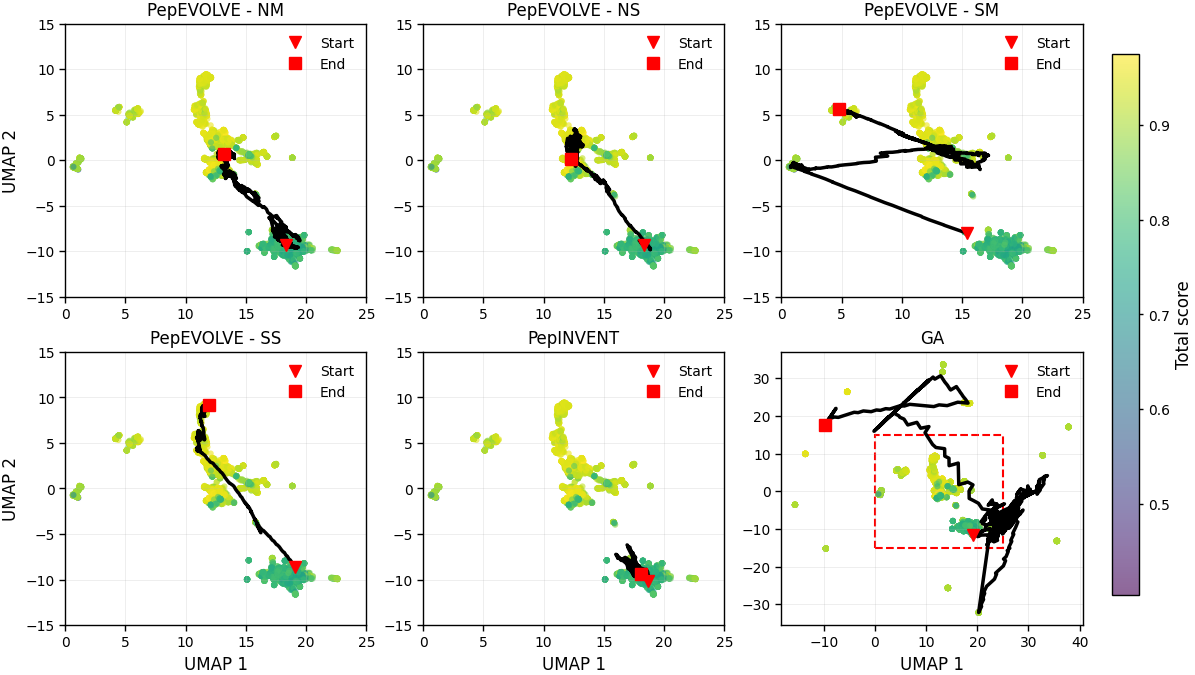

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# -----------------------------
# Bigger fonts (global) + thicker axes/ticks
# -----------------------------
plt.rcParams.update({
    "font.size": 11,          # base font
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
})

runs = df_plot["run"].dropna().astype(str).unique()
window = 30

# Focus the non-GA panels on the dense evolution region.
zoom_xlim = (0, 25)
zoom_ylim = (-15, 15)

n = len(runs)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3 * SINGLE_COL_IN, H_MED * nrows),
    constrained_layout=True
)
axes = np.ravel(axes)

sc_for_cbar = None

# -----------------------------
# Dot + marker sizing knobs
# -----------------------------
DOT_S = 20          # background scatter dot size (was 8)
START_END_MS = 8    # start/end marker size
LINE_LW = 2.5       # trajectory line width (was 2)

for i, run in enumerate(runs):
    ax = axes[i]
    dfr = df_plot[df_plot["run"] == run]

    dfr_smooth = (
        dfr.sort_values("Step")
            .assign(
                umap_x_s=lambda x: x["umap_x"].rolling(window, center=True).mean(),
                umap_y_s=lambda x: x["umap_y"].rolling(window, center=True).mean(),
            )
            .dropna(subset=["umap_x_s", "umap_y_s"])
    )

    sc = ax.scatter(
        df_plot["umap_x"],
        df_plot["umap_y"],
        c=df_plot["total_score"],
        s=DOT_S,
        alpha=0.6,
        linewidths=0,
    )
    if sc_for_cbar is None:
        sc_for_cbar = sc

    if len(dfr_smooth) > 1:
        ax.plot(
            dfr_smooth["umap_x_s"],
            dfr_smooth["umap_y_s"],
            color="k",
            lw=LINE_LW,
        )
        ax.plot(
            dfr_smooth["umap_x_s"].iloc[0],
            dfr_smooth["umap_y_s"].iloc[0],
            marker="v",
            color="r",
            linestyle="None",
            markersize=START_END_MS,
            label="Start",
        )
        ax.plot(
            dfr_smooth["umap_x_s"].iloc[-1],
            dfr_smooth["umap_y_s"].iloc[-1],
            marker="s",
            color="r",
            linestyle="None",
            markersize=START_END_MS,
            label="End",
        )
        ax.legend(frameon=False, loc="best")
    elif len(dfr_smooth) <= 1:
        ax.text(
            0.5, 0.5,
            "Not enough points\n(after smoothing)",
            transform=ax.transAxes,
            ha="center", va="center",
            fontsize=11, color="darkred"
        )

    if run == "GA":
        ax.add_patch(Rectangle(
            (zoom_xlim[0], zoom_ylim[0]),
            zoom_xlim[1] - zoom_xlim[0],
            zoom_ylim[1] - zoom_ylim[0],
            fill=False,
            edgecolor="red",
            linestyle="--",
            linewidth=1.5,
        ))
    else:
        ax.set_xlim(zoom_xlim)
        ax.set_ylim(zoom_ylim)

    ax.set_title(run)

    # grid
    ax.grid(True, which="major", alpha=0.25, linewidth=0.6)

    # Bigger tick marks + labels
    ax.tick_params(axis="both", which="major", length=4, width=1)

# Hide unused panels
for j in range(n, len(axes)):
    axes[j].axis("off")

# Colorbar (bigger label + ticks)
cbar = fig.colorbar(
    sc_for_cbar,
    ax=axes[:n],
    shrink=0.9,
    pad=0.02
)
cbar.set_label("Total score", fontsize=12)
cbar.ax.tick_params(labelsize=10, length=3, width=1)

# Shared labels (bigger)
axes[0].set_ylabel("UMAP 2", fontsize=12)
if nrows > 1:
    axes[ncols].set_ylabel("UMAP 2", fontsize=12)

for ax in axes[n-ncols:n]:
    ax.set_xlabel("UMAP 1", fontsize=12)

fig.savefig("umap_line_on_dots.pdf")
plt.show()

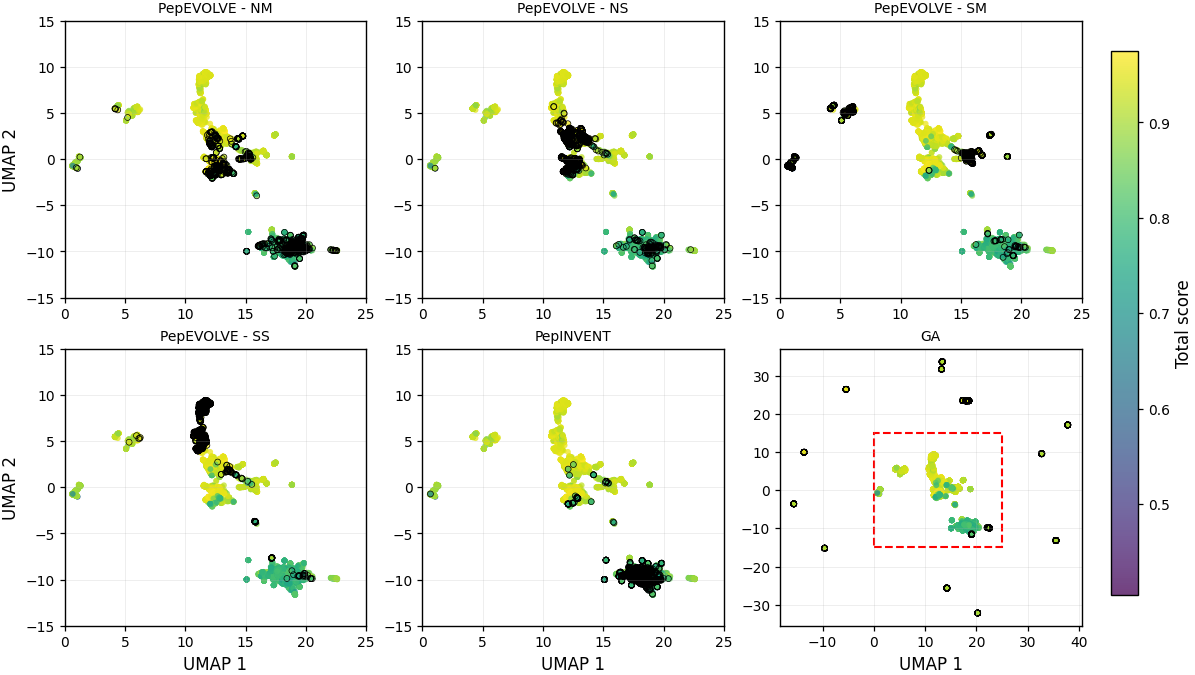

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

runs = df_plot["run"].dropna().unique()
steps = np.sort(df_plot["Step"].dropna().unique())

# Focus the non-GA panels on the dense evolution region.

n = len(runs)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3 * SINGLE_COL_IN, H_MED * nrows),
    constrained_layout=True
)
axes = np.ravel(axes)

# ---- color mapping for total_score (global, consistent) ----
scores = df_plot["total_score"].to_numpy()
vmin, vmax = np.nanmin(scores), np.nanmax(scores)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis

mappable_for_cbar = None

for i, run in enumerate(runs):
    ax = axes[i]
    dfr = df_plot[df_plot["run"] == run].copy()

    # Background scatter colored by total_score (shared across panels)
    sc = ax.scatter(
        df_plot["umap_x"],
        df_plot["umap_y"],
        c=df_plot["total_score"],
        cmap=cmap,
        norm=norm,
        s=18,
        linewidths=0,
        alpha=0.75
    )
    if mappable_for_cbar is None:
        mappable_for_cbar = sc

    # Overlay: this run, black outline
    ax.scatter(
        dfr["umap_x"],
        dfr["umap_y"],
        s=18,
        facecolors="none",
        edgecolors="k",
        linewidths=0.5
    )

    if run == "GA":
        ax.add_patch(Rectangle(
            (zoom_xlim[0], zoom_ylim[0]),
            zoom_xlim[1] - zoom_xlim[0],
            zoom_ylim[1] - zoom_ylim[0],
            fill=False,
            edgecolor="red",
            linestyle="--",
            linewidth=1.5,
        ))
    else:
        ax.set_xlim(zoom_xlim)
        ax.set_ylim(zoom_ylim)

    ax.set_title(str(run), fontsize=10)

    # JCIM-style grid
    ax.grid(True, which="major", axis="both", alpha=0.25, linewidth=0.6)

# Turn off unused axes
for j in range(n, len(axes)):
    axes[j].axis("off")

# Shared labels (cleaner for multi-panel)
axes[0].set_ylabel("UMAP 2")
if nrows > 1:
    axes[ncols].set_ylabel("UMAP 2")

for ax in axes[n-ncols:n]:
    ax.set_xlabel("UMAP 1")

# ---- ONE shared colorbar ----
cbar = fig.colorbar(mappable_for_cbar, ax=axes[:n], shrink=0.9, pad=0.02)
cbar.set_label("Total score")

# Save (vector first)
fig.savefig("umap_dots_on_dots.pdf")
# Optional raster:
# fig.savefig("Fig_umap_overlay_outline.png", dpi=600)

plt.show()

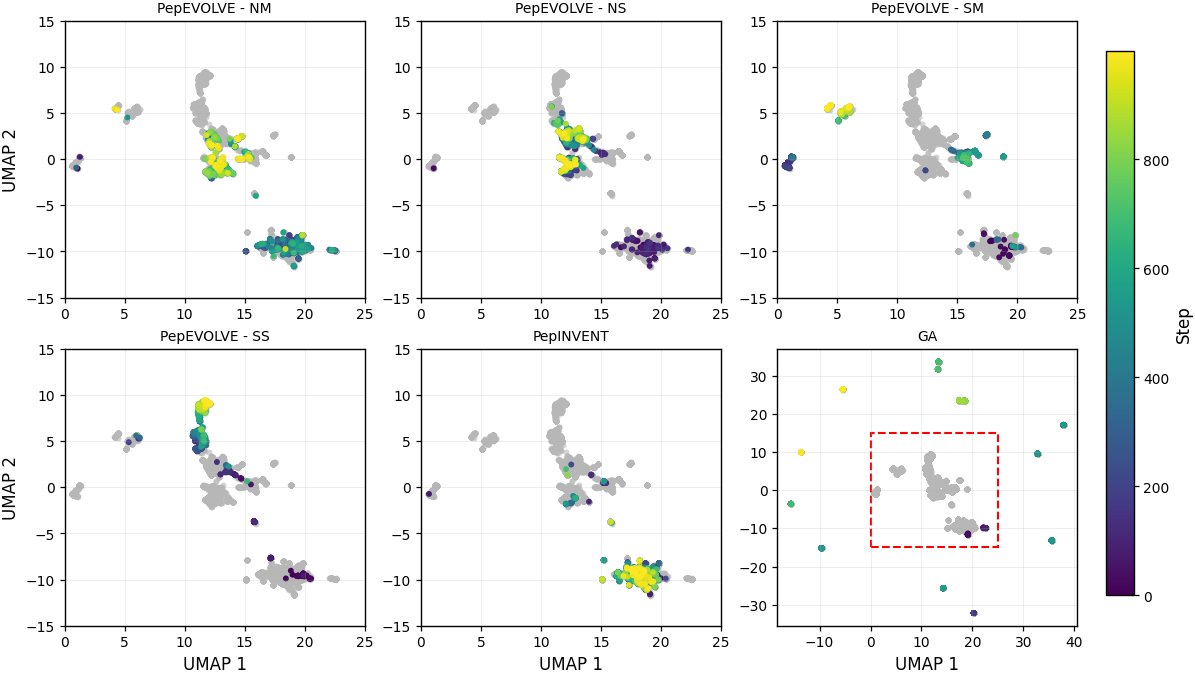

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

runs = df_plot["run"].dropna().unique()
steps = np.sort(df_plot["Step"].dropna().unique())

# Focus the non-GA panels on the dense evolution region.

n = len(runs)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3 * SINGLE_COL_IN, H_MED * nrows),
    constrained_layout=True
)
axes = np.ravel(axes)

# ---- color mapping for Step (global, consistent) ----
step_vals = df_plot["Step"].to_numpy()
vmin, vmax = np.nanmin(step_vals), np.nanmax(step_vals)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis

mappable_for_cbar = None

for i, run in enumerate(runs):
    ax = axes[i]
    dfr = df_plot[df_plot["run"] == run].copy()

    # Background: all points in gray
    ax.scatter(
        df_plot["umap_x"],
        df_plot["umap_y"],
        s=18,
        facecolors="#B7B7B7",
        linewidths=0,
        alpha=0.6,
        rasterized=True,   # keeps PDF light
    )

    # Overlay: this run, colored by Step
    sc = ax.scatter(
        dfr["umap_x"],
        dfr["umap_y"],
        c=dfr["Step"],
        cmap=cmap,
        norm=norm,
        s=18,
        linewidths=0,
    )
    if mappable_for_cbar is None:
        mappable_for_cbar = sc

    if run == "GA":
        ax.add_patch(Rectangle(
            (zoom_xlim[0], zoom_ylim[0]),
            zoom_xlim[1] - zoom_xlim[0],
            zoom_ylim[1] - zoom_ylim[0],
            fill=False,
            edgecolor="red",
            linestyle="--",
            linewidth=1.5,
        ))
    else:
        ax.set_xlim(zoom_xlim)
        ax.set_ylim(zoom_ylim)

    ax.set_title(str(run), fontsize=10)

    # JCIM-style grid
    ax.grid(True, which="major", axis="both", alpha=0.25, linewidth=0.6)

# Turn off unused axes
for j in range(n, len(axes)):
    axes[j].axis("off")

# Shared labels
axes[0].set_ylabel("UMAP 2")
if nrows > 1:
    axes[ncols].set_ylabel("UMAP 2")

for ax in axes[n-ncols:n]:
    ax.set_xlabel("UMAP 1")

# ---- ONE shared colorbar ----
cbar = fig.colorbar(mappable_for_cbar, ax=axes[:n], shrink=0.9, pad=0.02)
cbar.set_label("Step")

# Save (vector first)
fig.savefig("umap_step_colored.pdf")
# Optional raster:
# fig.savefig("Fig_umap_step_colored.png", dpi=600)

plt.show()

In [10]:
df_ga = dfs["GA"].copy()
top_ga = df_ga.loc[df_ga["total_score"].idxmax()]
mol = Chem.MolFromSmiles(top_ga["SMILES"])

writer = Chem.SDWriter("top_ga_peptide.sdf")
if mol is not None:
    mol.SetProp("total_score", str(top_ga["total_score"]))
    mol.SetProp("Step", str(top_ga["Step"]))
    mol.SetProp("SMILES", top_ga["SMILES"])
    writer.write(mol)
writer.close()
print(f"Saved: {top_ga['SMILES']}  (score={top_ga['total_score']:.4f})")

Saved: N2[C@@H](Cc1ccc(O)cc1)C(=O)N1[C@@H](CCC1)C(=O)N(C)[C@@H](CN(C)C(=O)N[C@H]1CC(=O)N(C)C1=O)C(=O)N(C)[C@@H]([C@H](Cc1n(CCOC)cnn1)C)C(=O)N[C@@H](CO)C(=O)N[C@@H](Cc1ccc(O)cc1)C(=O)N[C@@H](CCCNC(=N)N)C(=O)N(C)[C@@H](CN(C(C)C)C(=O)N1CCC[C@H]1CO)C(=O)N[C@@H]([C@@H](C)O)C2(=O)  (score=0.9518)
